**Prática de Realce e detecção de borda**

Exercícios retirados de:
http://homepages.inf.ed.ac.uk/rbf/HIPR2/featops.htm



In [56]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

1) Aplique os filtros  Sobel e Roberts nas imagens abaixo. Mostre, para o caso do Sobel, uma imagem representando a derivada em x e outra imagem representando a derivada em y

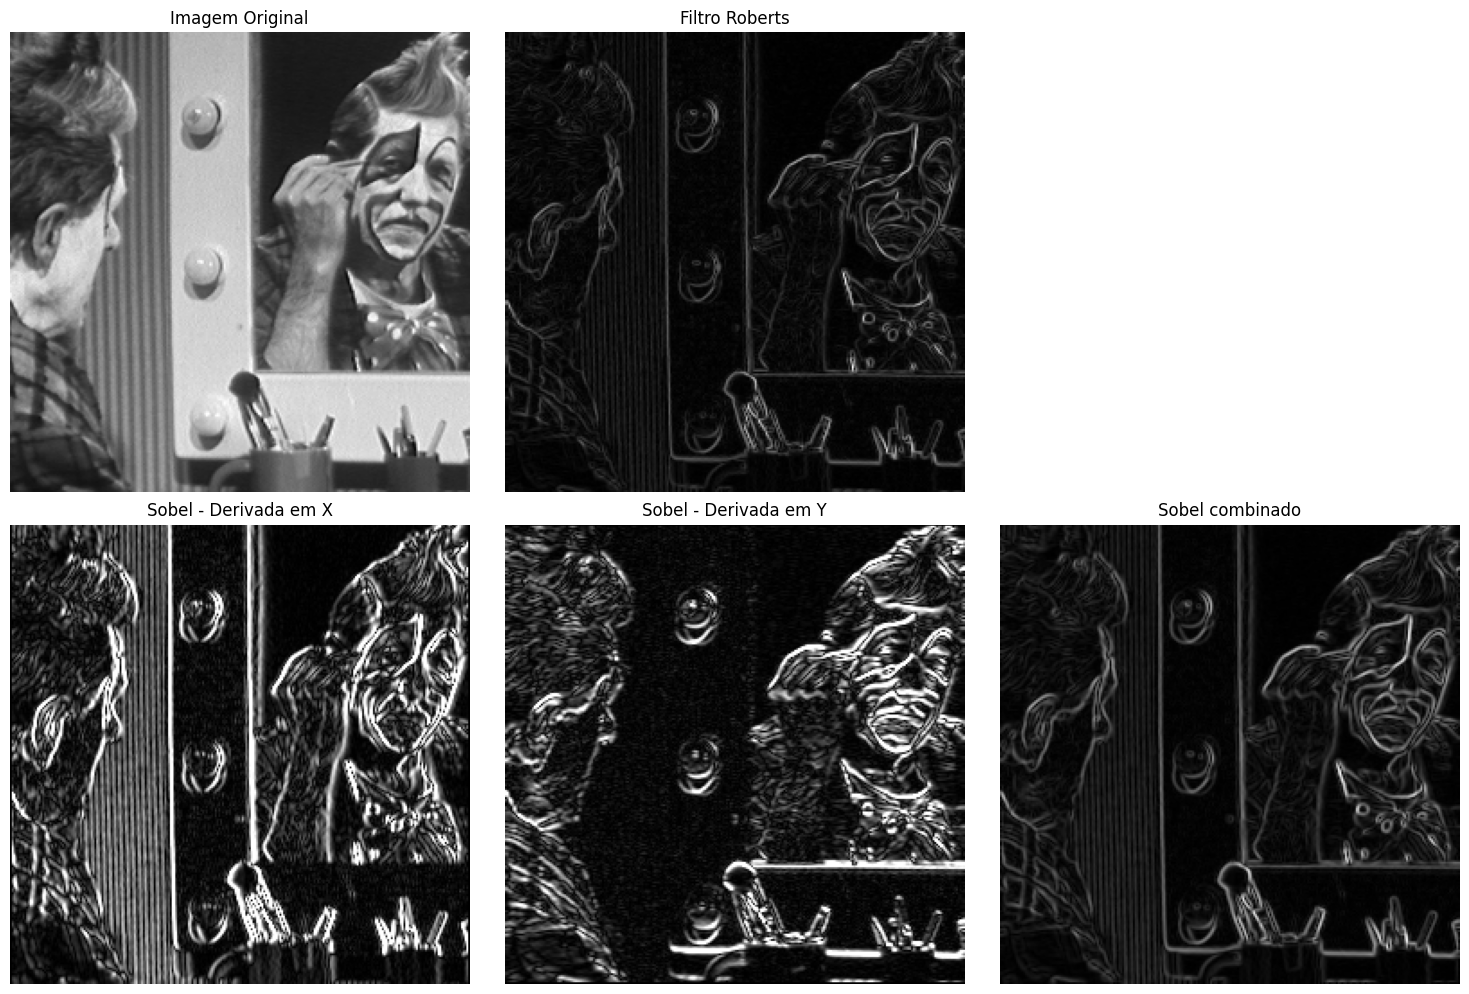

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img1 = cv2.imread("cln1.png", cv2.IMREAD_GRAYSCALE)

if img1 is None:
    print("Erro: A imagem não foi encontrada!")
else:
    #kernels do operador de Roberts Cruzado
    kernelx = np.array([[ 1,  0],
                                 [ 0, -1]], dtype=np.float32)
    kernely = np.array([[ 0,  1],
                                 [-1,  0]], dtype=np.float32)

    # Aplicando os filtros
    robertsx = cv2.filter2D(img1.astype(np.float32), -1, kernelx)
    robertsy = cv2.filter2D(img1.astype(np.float32), -1, kernely)

    roberts = cv2.magnitude(robertsx, robertsy)

    # Normalizando
    roberts = cv2.normalize(roberts, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

    # Sobel: Derivada em X
    sobelx = cv2.Sobel(img1, cv2.CV_64F, 1, 0, ksize=3)
    sobelx_vis = cv2.convertScaleAbs(sobelx)

    # Sobel: Derivada em Y
    sobely = cv2.Sobel(img1, cv2.CV_64F, 0, 1, ksize=3)
    sobely_vis = cv2.convertScaleAbs(sobely) # Converte de volta para uint8

    #Sobel combinada
    sobel = cv2.magnitude(sobelx, sobely)
    sobel = cv2.normalize(sobel, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

    plt.figure(figsize=(15, 10))

    # Imagem Original
    plt.subplot(2, 3, 1)
    plt.title('Imagem Original')
    plt.imshow(img1, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')

    # Filtro Roberts
    plt.subplot(2, 3, 2)
    plt.title('Filtro Roberts')
    plt.imshow(roberts, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')

    # Sobel - Derivada em X
    plt.subplot(2, 3, 4)
    plt.title('Sobel - Derivada em X')
    plt.imshow(sobelx_vis, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')

    # Sobel - Derivada em Y
    plt.subplot(2, 3, 5)
    plt.title('Sobel - Derivada em Y')
    plt.imshow(sobely_vis, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')

    # Filtro Sobel combinado
    plt.subplot(2, 3, 6)
    plt.title('Sobel combinado')
    plt.imshow(sobel, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

2) Utilizando a imagem do exercício anterior, realce as bordas utilizando (a) Filtro Laplaciano. (b) Unsharp masking. (c) Highboost filtering (escolher um k). (d) K <1 para atenuar

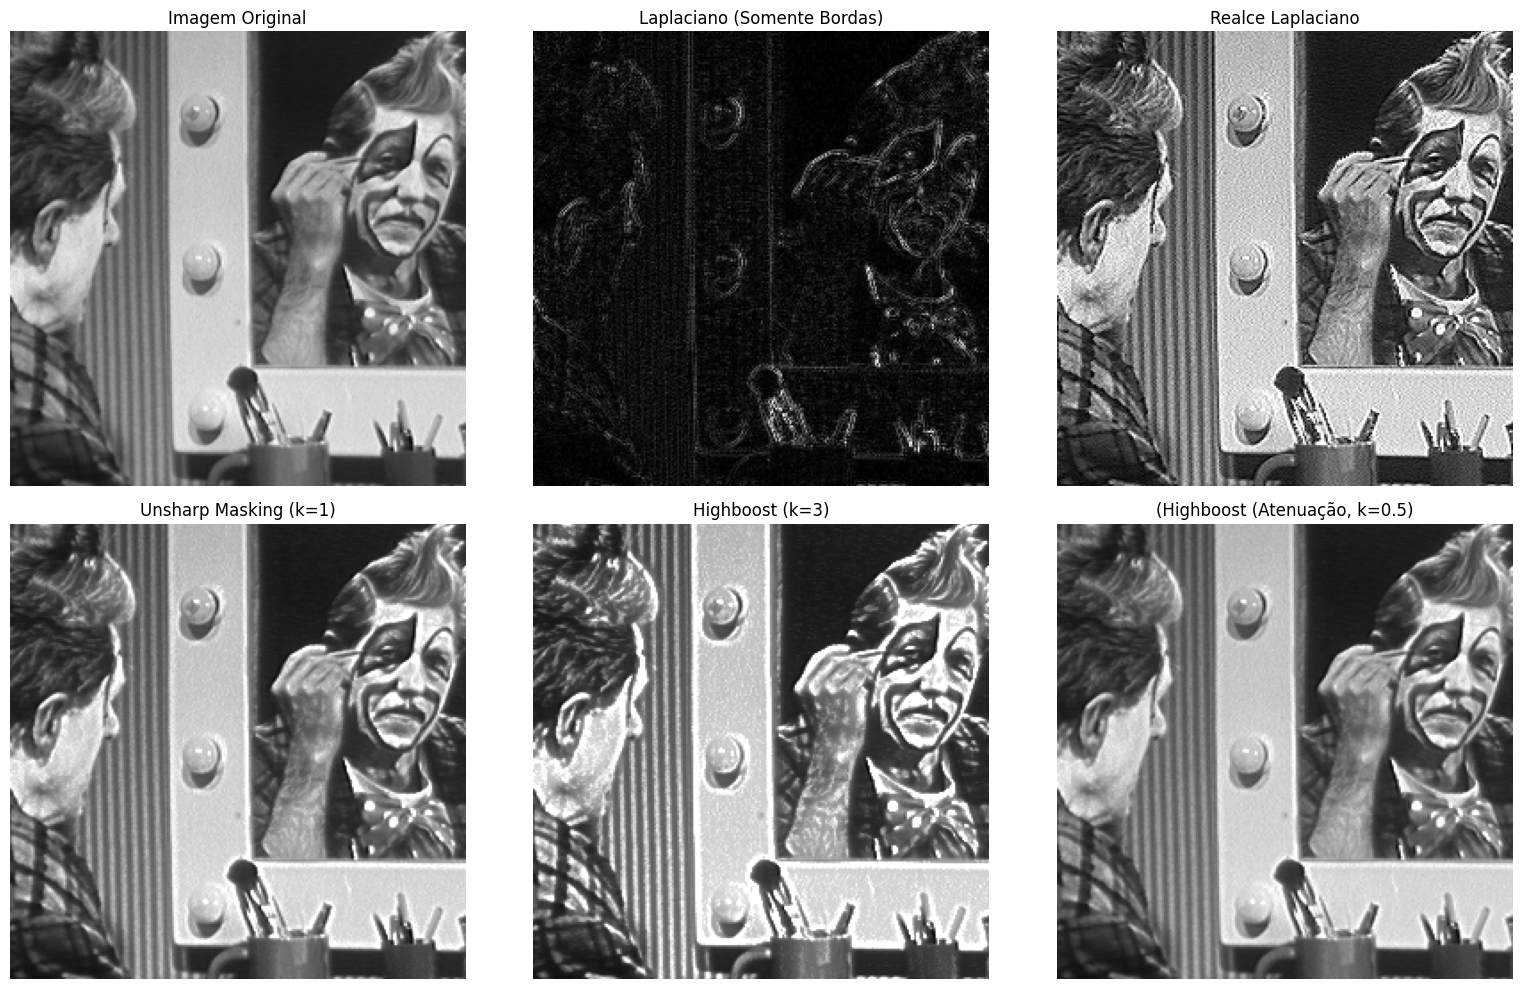

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img1 = cv2.imread("cln1.png", cv2.IMREAD_GRAYSCALE)

if img1 is None:
    print("Erro: A imagem não foi encontrada!")
else:
    laplacian = cv2.Laplacian(img1, cv2.CV_64F)

    #borda sobre fundo preto
    laplacian_abs = cv2.convertScaleAbs(laplacian)

    #realce: Subtraímos o Laplaciano
    #Laplaciano padrão tem o centro negativo, subtraí-lo realça as bordas.
    #convertScaleAbs para garantir que não haja overflow
    enhanced_laplacian = cv2.convertScaleAbs(img1.astype(np.float64) - laplacian)

    #Unsharp Masking

    #Desfoque Gaussiano
    blurred = cv2.GaussianBlur(img1, (9, 9), 10.0)
    #Máscara
    mask = cv2.subtract(img1, blurred)
    #Realce
    unsharp_image = cv2.add(img1, mask)

    #Highboost Filtering (k=3)
    #Highboost usa a mesma máscara do Unsharp sem multiplicar por 'k'
    k_high = 3.0
    highboost_image = cv2.convertScaleAbs(img1.astype(np.float64) + k_high * mask.astype(np.float64))

    #Highboost (K < 1)

    # Quando k < 1, estamos desfocando a imagem original
    k_low = 0.5
    attenuated_image = cv2.convertScaleAbs(img1.astype(np.float64) + k_low * mask.astype(np.float64))

    plt.figure(figsize=(16, 10))

    #Imagem Original
    plt.subplot(2, 3, 1)
    plt.title('Imagem Original')
    plt.imshow(img1, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')

    #Filtro Laplaciano (Bordas)
    plt.subplot(2, 3, 2)
    plt.title('Laplaciano (Somente Bordas)')
    plt.imshow(laplacian_abs, cmap='gray')
    plt.axis('off')

    #Laplaciano (Realce)
    plt.subplot(2, 3, 3)
    plt.title('Realce Laplaciano')
    plt.imshow(enhanced_laplacian, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')

    #Unsharp Masking
    plt.subplot(2, 3, 4)
    plt.title('Unsharp Masking (k=1)')
    plt.imshow(unsharp_image, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')

    #Highboost (k=3)
    plt.subplot(2, 3, 5)
    plt.title('Highboost (k=3)')
    plt.imshow(highboost_image, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')

    #Highboost (K <1 para atenuar)
    plt.subplot(2, 3, 6)
    plt.title('(Highboost (Atenuação, k=0.5)')
    plt.imshow(attenuated_image, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

3) Aplique o operador Sobel imagem original abaixo e obtenha as outras imagens conforme descrição. We can see that the intensity of many pixels on the surface is as high as along the actual edges. One reason is that the output of many edge pixels is greater than the maximum pixel value and therefore they are `cut off' at 255. To avoid this overflow we scale the range image by a factor 0.25 prior to the edge detection and then normalize the output, as can be seen in (c)

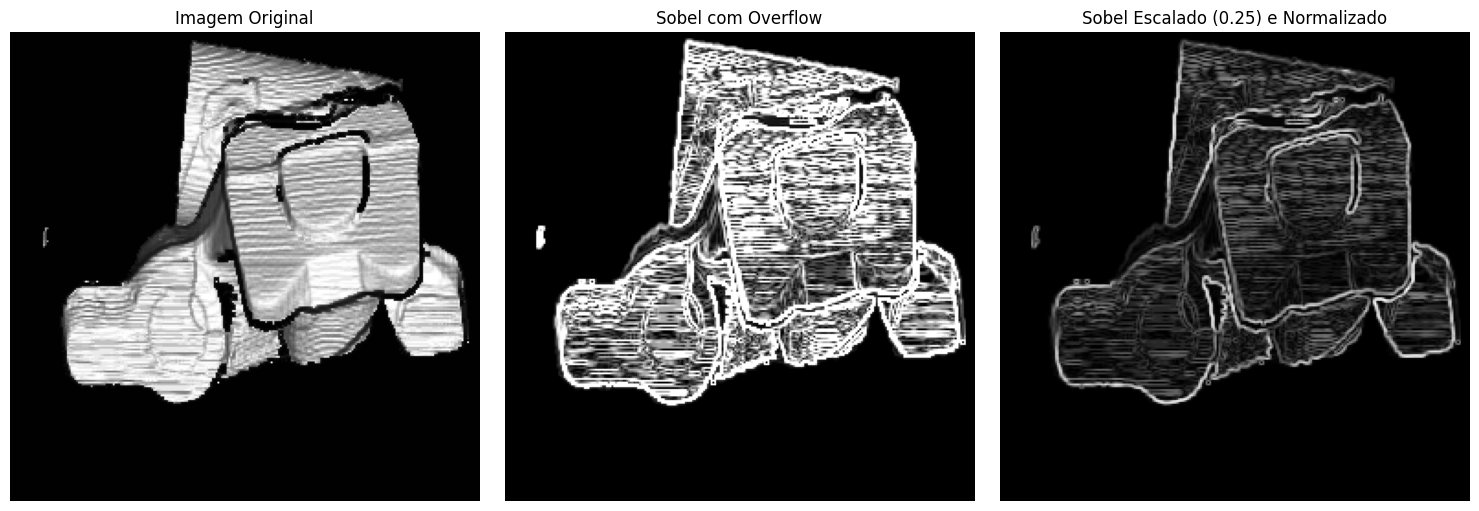

In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img1 = cv2.imread("ren1.png", cv2.IMREAD_GRAYSCALE)

if img1 is None:
    print("Erro: A imagem não foi encontrada!")
else:
    sobel_x = cv2.Sobel(img1, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(img1, cv2.CV_64F, 0, 1, ksize=3)

    sobel = cv2.magnitude(sobel_x, sobel_y)

    #Valores maiores que 255 viram 255.
    sobel_clipped = np.clip(sobel, 0, 255).astype(np.uint8)

    #Escalar a imagem original por um fator de 0.25
    escala_img1 = img1.astype(np.float64) * 0.25

    #Aplicar a detecção de bordas na imagem escalada
    escala_sobelx = cv2.Sobel(escala_img1, cv2.CV_64F, 1, 0, ksize=3)
    escala_sobely = cv2.Sobel(escala_img1, cv2.CV_64F, 0, 1, ksize=3)

    #Magnitude da imagem escalada
    magnitude = cv2.magnitude(escala_sobelx, escala_sobely)

    #Normalizar para intervalo [0, 255]
    sobel_normalizado = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

    plt.figure(figsize=(15, 5))

    #Imagem Original
    plt.subplot(1, 3, 1)
    plt.title('Imagem Original')
    plt.imshow(img1, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')

    #Sobel com Overflow
    plt.subplot(1, 3, 2)
    plt.title('Sobel com Overflow')
    plt.imshow(sobel_clipped, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')

    #Sobel Escalado e Normalizado
    plt.subplot(1, 3, 3)
    plt.title('Sobel Escalado (0.25) e Normalizado')
    plt.imshow(sobel_normalizado, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

4) Aplique o operador Sobel imagem original abaixo e obtenha a imagem binária após a limiarização utilizando o valor 150

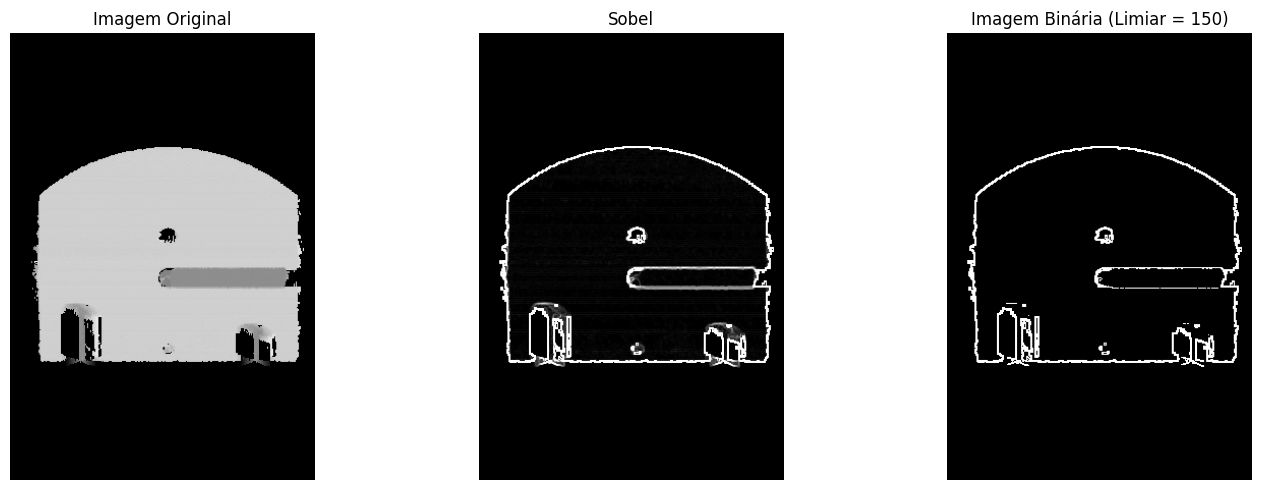

In [6]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img1 = cv2.imread("ufo2.png", cv2.IMREAD_GRAYSCALE)

if img1 is None:
    print("Erro: A imagem não foi encontrada!")
else:
    sobelx = cv2.Sobel(img1, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img1, cv2.CV_64F, 0, 1, ksize=3)

    sobel = cv2.magnitude(sobelx, sobely)

    sobel_8u = cv2.convertScaleAbs(sobel)

    limiar_definido = 150
    val_max = 255

    _, imagem_binaria = cv2.threshold(sobel_8u, limiar_definido,
                                        val_max, cv2.THRESH_BINARY)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.title('Imagem Original')
    plt.imshow(img1, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title('Sobel')
    plt.imshow(sobel_8u, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title('Imagem Binária (Limiar = 150)')
    plt.imshow(imagem_binaria, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

5) Aplique o operador Sobel imagem original abaixo e obtenha a imagem binária após a limiarização utilizando o valor 150

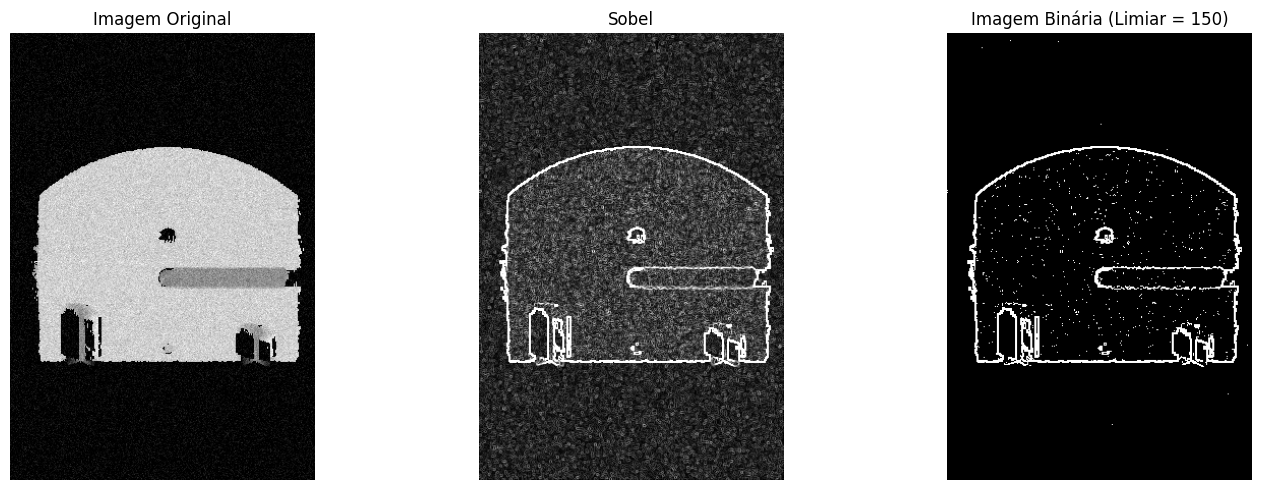

In [8]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img1 = cv2.imread("ufo2noi2.png", cv2.IMREAD_GRAYSCALE)

if img1 is None:
    print("Erro: A imagem não foi encontrada!")
else:
    sobelx = cv2.Sobel(img1, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img1, cv2.CV_64F, 0, 1, ksize=3)

    sobel = cv2.magnitude(sobelx, sobely)

    sobel_8u = cv2.convertScaleAbs(sobel)

    limiar_definido = 150
    val_max = 255

    _, imagem_binaria = cv2.threshold(sobel_8u, limiar_definido,
                                        val_max, cv2.THRESH_BINARY)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.title('Imagem Original')
    plt.imshow(img1, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title('Sobel')
    plt.imshow(sobel_8u, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title('Imagem Binária (Limiar = 150)')
    plt.imshow(imagem_binaria, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()